In [96]:
import warnings
warnings.filterwarnings('ignore')

In [97]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [98]:
pd.set_option('display.max_columns', 100)

In [99]:
dem_uncont = 34
rep_uncont = 31

In [100]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,54,Democrats
1,54,Democrats
2,46,Republicans
3,53,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,50,Republicans


In [101]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,38,1,0.0125,Republicans
1,39,1,0.0125,Republicans
2,40,3,0.0375,Republicans
3,41,3,0.0375,Republicans
4,42,14,0.1750,Republicans


In [102]:
np.unique(seat_sims['seats']).shape[0]

26

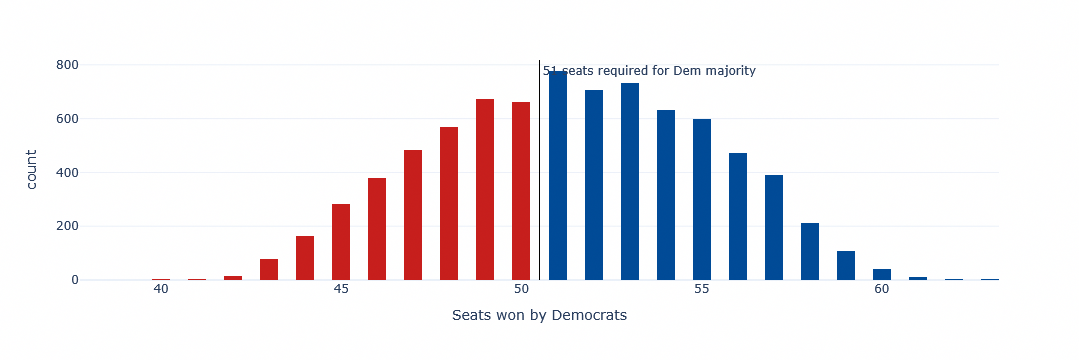

In [106]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [62]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348875,US Senate,seats
1,2026-09-27,58.550000,US Senate,chance
2,2026-09-27,3.826584,US Senate,seats_sd
3,2026-09-27,38.775987,AL,y_pred
4,2026-09-27,3.537250,AL,y_pred_sd


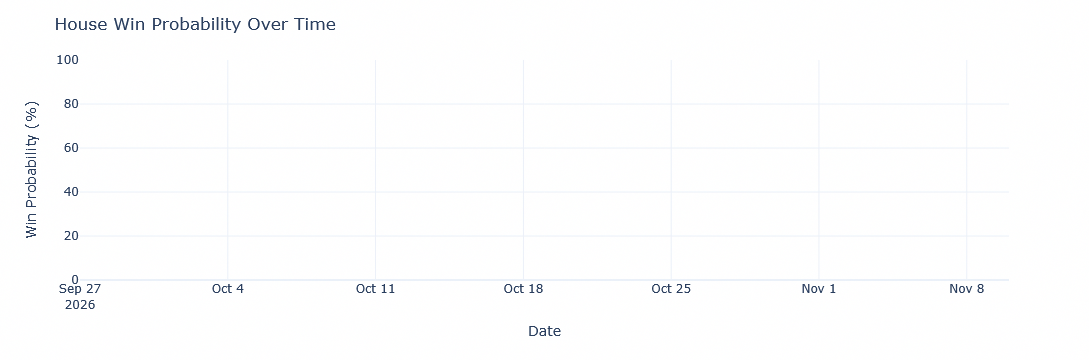

In [63]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

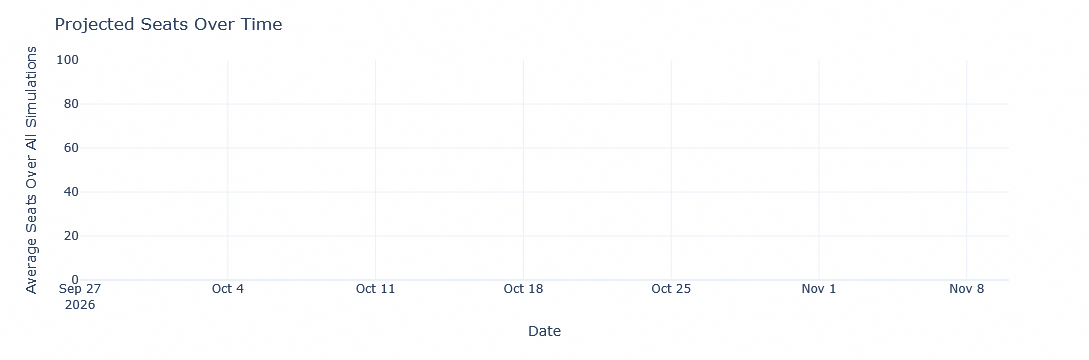

In [64]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [65]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [66]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [67]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.817178,-13.815435,-12.032083,-11.986622,-9.729710,-13.513401,-11.707510,-5.636609,-12.688449,-17.379604,-1.454182,-13.635622,-11.533994,-11.792439,-12.209831,-9.370989,-9.878146,-12.725357,-10.331568,-7.722096,-13.055191,-9.056549,-7.086021,-9.694382,-9.192399,-14.439762,-13.980004,-8.285338,-13.353930,-12.901956,-10.424518,-11.965578,-11.738890,-8.353801,-16.184936,-15.285904,-7.908351,-11.233101,-9.041756,-12.517023,-11.009408,-9.072205,-14.044311,-10.937142,-13.276724,-13.624400,-13.184174,-15.424821,-7.768583,-11.566001,...,-11.842078,-11.210270,-10.332332,-15.220530,-7.510232,-11.787180,-13.263185,-8.091558,-12.598639,-8.309557,-16.438597,-16.422692,-10.809253,-7.474054,-17.769365,-7.213587,-16.615282,-3.202091,-12.658189,-8.824642,-11.957438,-10.181511,-4.537008,-21.739732,-3.305750,-14.837086,-12.158350,-13.538054,-8.452030,-12.519138,-11.154238,-12.780806,-11.271566,-8.136171,-16.881188,-12.703349,-11.287561,-18.829888,-10.672204,-9.971876,-11.082462,-14.494998,-10.871315,-10.547355,-12.332239,-13.434922,-15.140385,-10.413125,-12.806953,-12.412296
AK,0.142819,5.304436,-0.403951,5.211343,-1.272107,4.298651,4.761207,5.179301,-0.850912,-5.926934,10.567928,0.138030,-1.307465,6.224089,-1.162710,2.792159,5.384613,4.387696,-0.694611,2.510585,6.500518,4.039196,1.976319,4.833807,4.406799,1.153608,2.108410,3.161609,-1.212849,1.337626,3.157632,5.317993,6.730945,8.051423,2.533480,-0.455619,3.164770,-0.143786,-1.282578,2.739821,-1.407694,3.279762,6.663195,3.856445,2.380956,-1.927758,0.683362,2.727733,1.816120,4.002927,...,3.741680,2.592743,9.682460,-0.750153,7.211770,2.481039,0.939604,3.290406,-1.735849,10.141157,2.003402,-1.284290,6.689444,2.957552,3.547904,1.158943,4.706482,1.684474,-0.986980,7.140260,1.261153,2.920262,8.177566,-0.244308,3.789378,-2.689193,5.966989,4.656628,3.132101,0.666990,-3.545343,4.987446,-1.098398,5.592727,1.443933,2.685615,2.951157,6.941256,3.693329,3.612344,-0.168405,3.964964,3.621666,-0.053301,3.685298,0.471600,1.437147,0.298469,3.151317,1.336530
AR,-11.276728,-13.075597,-9.455849,-12.142499,-10.934363,-9.122755,-10.196497,-6.754430,-15.315391,-15.098710,-2.274992,-12.839303,-13.694083,-8.225349,-13.177900,-11.827359,-11.162984,-9.646215,-12.004665,-8.352000,-12.338556,-11.831363,-8.124368,-8.297863,-12.514922,-9.952904,-12.380714,-8.998953,-12.353227,-12.158973,-9.513515,-10.208515,-7.640299,-8.412890,-14.571359,-14.035981,-7.298533,-10.843280,-12.354884,-11.425852,-11.483055,-7.364443,-13.183813,-15.019351,-13.656795,-11.872946,-9.997677,-14.959200,-11.851870,-12.836371,...,-13.885327,-12.473547,-9.099826,-14.474520,-4.843455,-13.333487,-13.711637,-12.439063,-11.278644,-5.005002,-15.617997,-13.201856,-9.221001,-8.589228,-14.534636,-5.711379,-16.513235,-2.184536,-10.301160,-9.588150,-12.818637,-7.354811,-5.909578,-16.507548,-4.373150,-17.477657,-10.150149,-17.173623,-6.276703,-10.782916,-10.174612,-11.899505,-10.630454,-3.498575,-18.538116,-10.660299,-8.702183,-13.447007,-7.032122,-13.128302,-12.178861,-11.721523,-9.638919,-8.141390,-12.315533,-14.359689,-18.022073,-12.272958,-8.697886,-11.793610
CO,11.326052,12.110970,7.185028,14.034327,8.787700,12.477088,14.273654,13.168411,10.737825,7.067243,13.229862,13.719260,10.835758,16.096387,7.851950,15.581501,13.634155,11.722670,6.732119,6.002042,12.857507,18.619895,9.824648,16.356965,13.609849,11.405244,11.232158,19.981624,7.649488,13.450007,14.008714,10.391091,9.308507,10.404475,11.693360,5.735584,16.245746,11.127806,15.348721,9.131849,12.982085,11.957586,11.589959,13.523700,10.520891,11.656675,7.577026,11.041514,12.320407,9.461217,...,13.738643,8.563844,17.338819,

In [68]:
sim_corr = post_untransp.corr()

In [69]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.519279,0.740581,0.489767,0.497603,0.706890,0.532606,0.737682,0.708992,0.744998,0.740103,0.541602,0.752431,0.738781,0.524612,0.735764,0.709790,0.744338,0.702778,0.726987,0.505545,0.506815,0.509778,0.707637,0.508530,0.758784,0.508354,0.492375,0.493011,0.513887,0.559328,0.704889,0.506767,0.742009,0.739755
AK,0.519279,1.000000,0.517185,0.522021,0.525438,0.501034,0.559372,0.526559,0.503581,0.518154,0.518369,0.566221,0.524392,0.510208,0.560861,0.511913,0.499867,0.517664,0.499141,0.515428,0.561245,0.539587,0.553693,0.497853,0.551417,0.521097,0.547387,0.549572,0.537972,0.541812,0.597592,0.507683,0.544635,0.520795,0.519564
AR,0.740581,0.517185,1.000000,0.487444,0.500014,0.703897,0.527245,0.736828,0.700020,0.741694,0.738079,0.537347,0.742270,0.731602,0.523998,0.729160,0.700501,0.725908,0.694566,0.721702,0.509062,0.500579,0.502603,0.705349,0.504761,0.744357,0.501883,0.496421,0.495535,0.515455,0.557040,0.702417,0.498847,0.735920,0.735138
CO,0.489767,0.522021,0.487444,1.000000,0.708943,0.654501,0.550444,0.498035,0.655174,0.503333,0.488153,0.549463,0.504026,0.486158,0.538401,0.487531,0.643112,0.493826,0.654270,0.477879,0.710899,0.715784,0.720353,0.647407,0.706785,0.499997,0.710476,0.702052,0.699263,0.530928,0.571408,0.656290,0.703954,0.496848,0.494051
DE,0.497603,0.525438,0.500014,0.708943,1.000000,0.667670,0.542838,0.504820,0.665162,0.508823,0.499967,0.547727,0.503509,0.501699,0.549152,0.501766,0.663557,0.499256,0.665401,0.489525,0.718804,0.725928,0.729415,0.661329,0.716096,0.515643,0.710025,0.712387,0.709485,0.521146,0.577925,0.661959,0.719015,0.499415,0.509306


In [70]:
post.shape

(35, 8000)

In [71]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [72]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:06<00:00, 1191.35it/s]


array(['IA', 'MI', 'TX', ..., 'IA', 'WY', 'AK'],
      shape=(8000,), dtype='<U32')

In [73]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.549249,47.730058,1,95.460117,61.682221,3.503960,99.9625,4,54.895979,68.585051
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.642502,48.524126,1,97.048252,63.225447,3.504410,99.9875,5,56.387415,70.181412


In [74]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.549249,47.730058,1,95.460117,61.682221,3.503960,99.9625,4,54.895979,68.585051,0.1875
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.642502,48.524126,1,97.048252,63.225447,3.504410,99.9875,5,56.387415,70.181412,0.7500


In [75]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-8.620113,0,0,47.467017,7.840377,45.029856,7.840377,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,7.840377,2.800067,-2.437161,8.235201,17.834942,0,35.669884,50.641184,3.537786,57.4000,16,43.850479,57.637919,10.925
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-8.620113,0,0,48.029068,6.535460,44.852512,6.535460,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,6.535460,2.556455,-3.176556,-3.213635,37.909568,0,75.819136,51.285891,3.627430,63.9375,32,44.203239,58.482202,10.475
13,13,Maine,Troy Jackson,Susan Collins,False,True,R,ME,no_match,"COLLINS, SUSAN M.",0.00,10501136.60,10501136.60,0.000000,100.000000,3.820912,53.544306,94.249770,0.897865,1.689465,0.930085,0.342309,36.189622,526309,836050,1362359,38.632181,61.367819,0.987401,-8.620113,0,1,48.007447,4.721448,45.913710,4.721448,New England,2026,0.0,0.00000,0.00000,3,Senate,0.000000,4.721448,2.172889,-2.093737,16.261938,-50.000000,-1,-100.000000,50.080152,3.585803,50.4625,14,42.974802,57.151934,9.925
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-8.620113,0,0,46.039942,5.006542,45.185154,5.006542,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,5.006542,2.237530,-0.854788,-3.565553,2.558612,0,5.117224,49.741051,3.515843,46.0375,10,42.746445,56.626376,9.750
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-8.620113,0,1,47.441977,1.841174,43.651111,1.841174,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,1.841174,1.356899,-3.790866,-1.912994,33.220254,-1,66.440509,50.517500,3.464438,56.0750,25,43.584583,57.368858,9.375


In [76]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [77]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.549249,47.730058,1,95.460117,61.682221,3.503960,99.9625,4,54.895979,68.585051,0.1875,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.620113,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.642502,48.524126,1,97.048252,63.225447,3.504410,99.9875,5,56.387415,70.181412,0.7500,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [79]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [82]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [83]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7


In [84]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.9500,0.0,100.0,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,19.9875,80.0,20.0,80.0%,20.0%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.8750,0.1,99.9,<1%,>99%


In [85]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.9500,0.0,100.0,<1%,>99%,8.433197
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,19.9875,80.0,20.0,80.0%,20.0%,19.370781
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.620113,0,1,38.189521,0.494462,49.190029,0.494462,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.494462,0.703180,11.000508,-22.000930,-8.541719,-1,-17.083438,39.138984,3.568479,0.1250,3,32.044011,46.037217,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.7,99.8750,0.1,99.9,<1%,>99%,9.617954


In [86]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.620113,0,0,32.000000,0.053754,47.000000,0.053754,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.053754,0.231849,15.000000,-21.006329,-49.622498,0,-99.244996,38.775987,3.537250,0.0500,1,31.965134,45.846477,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.9500,0.0,100.0,<1%,>99%,8.433197,D+8.4
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.620113,0,1,49.473113,2.323437,48.488694,2.323437,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.323437,1.524283,-0.984419,-4.290492,49.948144,-1,99.896288,52.838828,3.401147,80.0125,2,46.183071,59.633650,5.5375,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,19.9875,80.0,20.0,80.0%,20.0%,19.370781,D+19.4


In [87]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.4,D+8.4,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">80.0%</p>","<p style=""color:red;"">20.0%</p>",D+5.7,D+19.4,5.5375
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.7,D+9.6,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.4,D+12.1,0.1875
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+26.5,D+11.5,0.7500


In [88]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

7.33774565807685

In [89]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.348875
1,chamber_win_chance,58.550000
0,sv_bias,7.337746


In [90]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [91]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,58.55,51.348875
1,Republicans,41.45,48.651125


In [94]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [95]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')